<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/two_fluid_transient_slug_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Two-fluid multiphase flow, Beggs–Brill comparison, and transients

**Audience.** Flow-assurance, process, and production engineers who want a transparent
comparison between an empirical steady correlation and a mechanistic transient model.

**Learning objectives**

After completing this notebook you can:

1. build one reproducible three-phase feed and use it in both pipeline models;
2. compare `TwoFluidPipe` with `PipeBeggsAndBrills` at identical conditions;
3. inspect pressure, liquid holdup, phase velocity, and flow-regime differences;
4. map the stratified, slug, and annular operating regions;
5. simulate rate-change transients from a slug-prone operating point; and
6. compare both models for an oil-and-gas wellstream in an S-riser;
7. examine sag liquid accumulation during turndown; and
8. distinguish screening predictions from validated slug-arrival forecasting.

## Model boundary

`PipeBeggsAndBrills` is an empirical steady-state screening model. `TwoFluidPipe` solves
separate gas- and liquid-phase conservation equations and can advance the state in time.
That makes the two-fluid model suitable for inventory and pressure-wave studies, but does
not make every predicted slug statistic a validated field forecast.

This notebook demonstrates **slug-regime prediction** through a reproducible operating map
and a transient started inside that regime. It does not calibrate stochastic individual-slug
arrival distributions. Quantitative slug arrival, severe slugging, and separator surge
design require field or high-fidelity benchmark data.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "neqsim",
        ],
        check=True,
    )

The setup cell installs the latest public PyPI release only when NeqSim is absent. A clean
Colab runtime installs once; an already prepared runtime is left unchanged.

In [2]:
from importlib.metadata import version
import platform

import jpype
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid


NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = str(
    jpype.JClass("java.lang.System").getProperty("java.version")
)
JavaUUID = jpype.JClass("java.util.UUID")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (8.4, 4.8),
        "figure.dpi": 110,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {PYTHON_VERSION}")
print(f"Java version: {JAVA_VERSION}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java version: 17.0.19


## Governing equations

For phase $k$, gas or liquid, the one-dimensional mass balance is

$$
\frac{\partial}{\partial t}
\left(\alpha_k \rho_k A\right)
+
\frac{\partial}{\partial x}
\left(\alpha_k \rho_k u_k A\right)
=
\Gamma_k
$$

and the phase momentum balance has the form

$$
\frac{\partial}{\partial t}
\left(\alpha_k \rho_k u_k A\right)
+
\frac{\partial}{\partial x}
\left(\alpha_k \rho_k u_k^2 A+\alpha_k pA\right)
=
F_{w,k}+F_{i,k}+\alpha_k\rho_k gA\sin\theta
$$

Here $\alpha_k$ is holdup, $\rho_k$ is density, $u_k$ is phase velocity, $A$
is pipe area, $\Gamma_k$ is interphase mass transfer, and the force terms contain wall
and interfacial shear. The closure

$$
\alpha_g+\alpha_L=1
$$

connects the two phase areas. Superficial and in-situ velocities are related by
$j_k=\alpha_k u_k$.

Beggs–Brill instead supplies empirical holdup and friction closures to a steady pressure
balance. Agreement is therefore not imposed; the difference is a useful model-form
screening result.

## Calculation sequence

The same flashed feed, pipe dimensions, roughness, discretization, and inlet state are used
for both steady models. The transient then reuses the two-fluid case and changes only the
inlet mass rate.

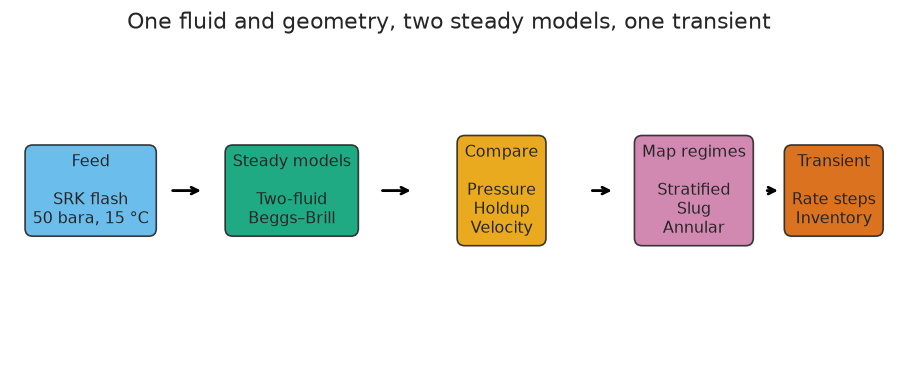

In [3]:
fig, axis = plt.subplots(figsize=(9.4, 3.5))
axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.0, 1.0)
axis.axis("off")

steps = [
    (0.09, "Feed", "SRK flash\n50 bara, 15 °C", "#56B4E9"),
    (0.32, "Steady models", "Two-fluid\nBeggs–Brill", "#009E73"),
    (0.56, "Compare", "Pressure\nHoldup\nVelocity", "#E69F00"),
    (0.78, "Map regimes", "Stratified\nSlug\nAnnular", "#CC79A7"),
    (0.94, "Transient", "Rate steps\nInventory", "#D55E00"),
]

for center_x, title, detail, color in steps:
    axis.text(
        center_x,
        0.53,
        f"{title}\n\n{detail}",
        ha="center",
        va="center",
        fontsize=9.5,
        bbox={
            "boxstyle": "round,pad=0.48",
            "facecolor": color,
            "edgecolor": "#222222",
            "alpha": 0.88,
        },
    )

for start_x, end_x in [
    (0.18, 0.22),
    (0.42, 0.46),
    (0.66, 0.69),
    (0.86, 0.88),
]:
    axis.annotate(
        "",
        xy=(end_x, 0.53),
        xytext=(start_x, 0.53),
        arrowprops={"arrowstyle": "->", "lw": 1.7},
    )

axis.set_title("One fluid and geometry, two steady models, one transient")
plt.show()

## Reproducible fluid and base case

The synthetic feed contains gas, condensate-range hydrocarbons, and water. It avoids
private assay files while still producing multiple phases at the pipeline inlet.

Base geometry:

- length: 600 m;
- internal diameter: 0.15 m;
- absolute roughness: 45 µm;
- 30 axial cells; and
- horizontal, isothermal screening.

The compact line keeps the transient suitable for a hosted Colab runtime. The workflow,
not the dimensions, is the reusable part.

In [4]:
composition = {
    "methane": 0.720,
    "ethane": 0.080,
    "propane": 0.055,
    "i-butane": 0.025,
    "n-butane": 0.025,
    "n-pentane": 0.035,
    "n-heptane": 0.035,
    "water": 0.025,
}

case_fluid = fluid("srk")
for component, fraction in composition.items():
    case_fluid.addComponent(component, fraction)

case_fluid.setMixingRule(2)
case_fluid.setMultiPhaseCheck(True)
case_fluid.setTemperature(15.0, "C")
case_fluid.setPressure(50.0, "bara")
TPflash(case_fluid)
case_fluid.initPhysicalProperties()

phase_rows = []
for phase_index in range(case_fluid.getNumberOfPhases()):
    phase = case_fluid.getPhase(phase_index)
    phase_rows.append(
        {
            "phase": str(phase.getPhaseTypeName()),
            "mole split": case_fluid.getBeta(phase_index),
            "density [kg/m³]": phase.getDensity("kg/m3"),
        }
    )

phase_table = pd.DataFrame(phase_rows)
display(phase_table.round(5))

,phase,mole split,density [kg/m³]
0,gas,0.79139,48.07971
1,oil,0.18390,556.90329
2,aqueous,0.02471,1011.76020


In [5]:
BASE_RATE_KG_S = 1.5
BASE_LENGTH_M = 600.0
BASE_DIAMETER_M = 0.15
ROUGHNESS_M = 4.5e-5
BASE_SECTIONS = 30


def build_stream(name, source_fluid, mass_rate_kg_s):
    stream = jneqsim.process.equipment.stream.Stream(
        name,
        source_fluid.clone(),
    )
    stream.setFlowRate(mass_rate_kg_s, "kg/sec")
    stream.setTemperature(15.0, "C")
    stream.setPressure(50.0, "bara")
    stream.run()
    return stream


def run_beggs_case(
    name,
    source_fluid,
    mass_rate_kg_s,
    diameter_m,
    length_m,
    sections,
):
    stream = build_stream(
        f"{name} feed",
        source_fluid,
        mass_rate_kg_s,
    )
    pipe = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills(
        name,
        stream,
    )
    pipe.setLength(length_m)
    pipe.setDiameter(diameter_m)
    pipe.setPipeWallRoughness(ROUGHNESS_M)
    pipe.setElevation(0.0)
    pipe.setNumberOfIncrements(sections)
    pipe.setRunIsothermal(True)
    pipe.run()
    return stream, pipe


def run_two_fluid_case(
    name,
    source_fluid,
    mass_rate_kg_s,
    diameter_m,
    length_m,
    sections,
):
    stream = build_stream(
        f"{name} feed",
        source_fluid,
        mass_rate_kg_s,
    )
    pipe = jneqsim.process.equipment.pipeline.TwoFluidPipe(
        name,
        stream,
    )
    pipe.setLength(length_m)
    pipe.setDiameter(diameter_m)
    pipe.setRoughness(ROUGHNESS_M)
    pipe.setNumberOfSections(sections)
    pipe.setElevationProfile(np.zeros(sections).tolist())
    pipe.setThermodynamicUpdateInterval(10)
    pipe.setSteadyStateFlashInterval(10)
    pipe.setSteadyStateMaxWallClockTime(30.0)
    pipe.run()
    return stream, pipe

## Steady comparison at one slug-prone operating point

Both calculations start from the same 1.5 kg/s stream. No result from one pipe is used to
initialize or tune the other.

In [6]:
beggs_feed, beggs_pipe = run_beggs_case(
    "Beggs-Brill base",
    case_fluid,
    BASE_RATE_KG_S,
    BASE_DIAMETER_M,
    BASE_LENGTH_M,
    BASE_SECTIONS,
)
two_feed, two_pipe = run_two_fluid_case(
    "Two-fluid base",
    case_fluid,
    BASE_RATE_KG_S,
    BASE_DIAMETER_M,
    BASE_LENGTH_M,
    BASE_SECTIONS,
)

beggs_x_m = np.asarray(beggs_pipe.getLengthProfile())
beggs_pressure_bar = np.asarray(beggs_pipe.getPressureProfile())
beggs_holdup = np.asarray(beggs_pipe.getLiquidHoldupProfile())
beggs_vsg_m_s = np.asarray(
    beggs_pipe.getGasSuperficialVelocityProfile()
)
beggs_vsl_m_s = np.asarray(
    beggs_pipe.getLiquidSuperficialVelocityProfile()
)

two_x_m = np.asarray(two_pipe.getPositionProfile())
two_pressure_bar = (
    np.asarray(two_pipe.getPressureProfile()) / 1.0e5
)
two_holdup = np.asarray(two_pipe.getLiquidHoldupProfile())
two_gas_velocity_m_s = np.asarray(
    two_pipe.getGasVelocityProfile()
)
two_liquid_velocity_m_s = np.asarray(
    two_pipe.getLiquidVelocityProfile()
)
two_vsg_m_s = (1.0 - two_holdup) * two_gas_velocity_m_s
two_vsl_m_s = two_holdup * two_liquid_velocity_m_s

beggs_regimes = sorted(
    {
        str(value)
        for value in beggs_pipe.getFlowRegimeProfileList()
    }
)
two_regimes = sorted(
    {
        str(value)
        for value in two_pipe.getFlowRegimeProfile()
    }
)

In [7]:
steady_summary = pd.DataFrame(
    [
        {
            "model": "Beggs–Brill",
            "outlet pressure [bara]": beggs_pressure_bar[-1],
            "pressure drop [bar]": (
                beggs_pressure_bar[0] - beggs_pressure_bar[-1]
            ),
            "mean liquid holdup [-]": beggs_holdup.mean(),
            "regime(s)": ", ".join(beggs_regimes),
        },
        {
            "model": "Two-fluid",
            "outlet pressure [bara]": two_pressure_bar[-1],
            "pressure drop [bar]": (
                two_pressure_bar[0] - two_pressure_bar[-1]
            ),
            "mean liquid holdup [-]": two_holdup.mean(),
            "regime(s)": ", ".join(two_regimes),
        },
    ]
)

display(steady_summary.round(6))

,model,outlet pressure [bara],pressure drop [bar],mean liquid holdup [-],regime(s)
0,Beggs–Brill,49.960671,0.039329,0.240769,SEGREGATED
1,Two-fluid,49.939605,0.060395,0.176081,SLUG


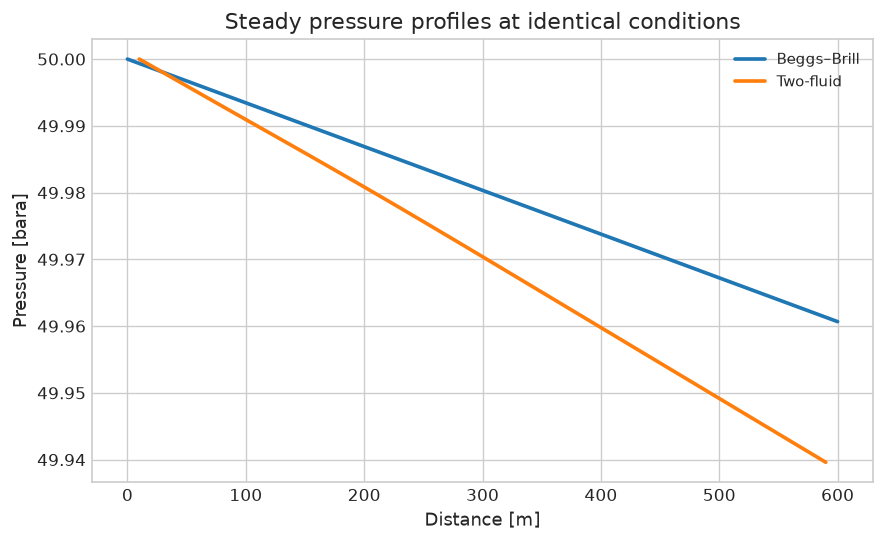

In [8]:
fig, axis = plt.subplots()
axis.plot(
    beggs_x_m,
    beggs_pressure_bar,
    lw=2.2,
    label="Beggs–Brill",
)
axis.plot(
    two_x_m,
    two_pressure_bar,
    lw=2.2,
    label="Two-fluid",
)
axis.set(
    xlabel="Distance [m]",
    ylabel="Pressure [bara]",
    title="Steady pressure profiles at identical conditions",
)
axis.legend()
plt.show()

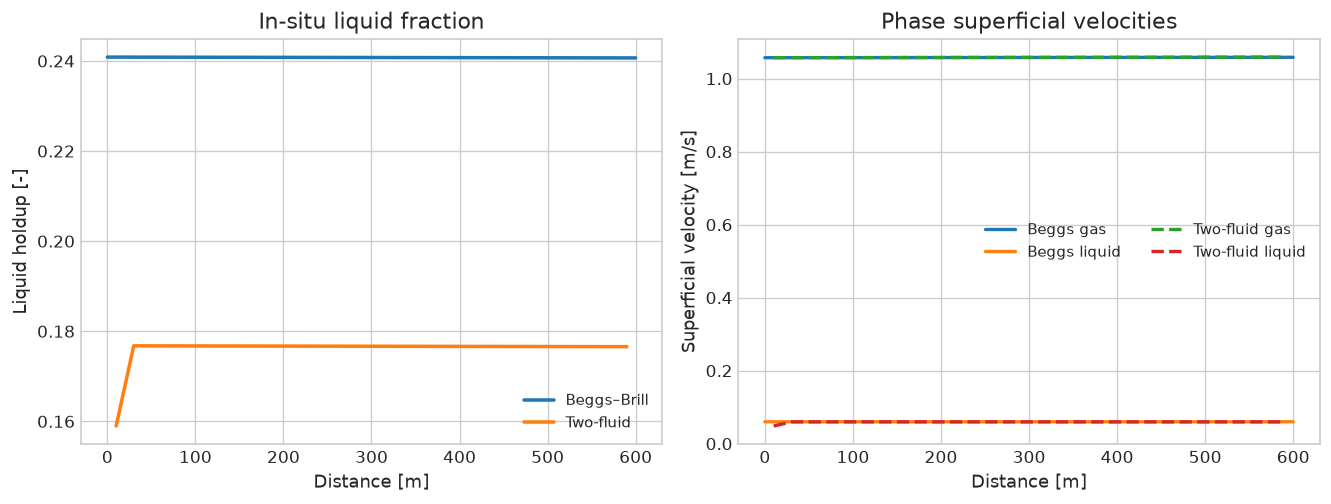

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.3))

axes[0].plot(
    beggs_x_m,
    beggs_holdup,
    lw=2.1,
    label="Beggs–Brill",
)
axes[0].plot(
    two_x_m,
    two_holdup,
    lw=2.1,
    label="Two-fluid",
)
axes[0].set(
    xlabel="Distance [m]",
    ylabel="Liquid holdup [-]",
    title="In-situ liquid fraction",
)
axes[0].legend()

axes[1].plot(
    beggs_x_m,
    beggs_vsg_m_s,
    lw=2.0,
    label="Beggs gas",
)
axes[1].plot(
    beggs_x_m,
    beggs_vsl_m_s,
    lw=2.0,
    label="Beggs liquid",
)
axes[1].plot(
    two_x_m,
    two_vsg_m_s,
    "--",
    lw=2.0,
    label="Two-fluid gas",
)
axes[1].plot(
    two_x_m,
    two_vsl_m_s,
    "--",
    lw=2.0,
    label="Two-fluid liquid",
)
axes[1].set(
    xlabel="Distance [m]",
    ylabel="Superficial velocity [m/s]",
    title="Phase superficial velocities",
)
axes[1].legend(ncol=2)

fig.tight_layout()
plt.show()

The two pressure drops are compared with

$$
\delta_{\Delta p}
=
\frac{
\left|\Delta p_{\mathrm{2F}}-\Delta p_{\mathrm{BB}}\right|
}{
\Delta p_{\mathrm{BB}}
}
$$

A large $\delta_{\Delta p}$ is not automatically an error. It indicates model-form
sensitivity that should be resolved with suitable loop, laboratory, or field data. The
phase velocities remain positive and both models predict a small pressure loss relative to
the approximately 50 bara operating pressure.

In [10]:
beggs_dp_bar = beggs_pressure_bar[0] - beggs_pressure_bar[-1]
two_dp_bar = two_pressure_bar[0] - two_pressure_bar[-1]
relative_dp_difference = abs(two_dp_bar - beggs_dp_bar) / beggs_dp_bar
steady_mass_residual_kg_s = abs(
    two_feed.getFlowRate("kg/sec")
    - two_pipe.getOutletStream().getFlowRate("kg/sec")
)

print(
    "Relative pressure-drop difference: "
    f"{relative_dp_difference:.3%}"
)
print(
    "Two-fluid steady mass-flow residual: "
    f"{steady_mass_residual_kg_s:.3e} kg/s"
)

Relative pressure-drop difference: 53.562%
Two-fluid steady mass-flow residual: 0.000e+00 kg/s


## Operating map: where does the two-fluid model predict slug flow?

Diameter and flow rate are screened independently from fresh stream and pipe objects. Each
point is a steady two-fluid calculation. The dominant regime map is more reproducible than
a stochastic slug-arrival sequence and directly identifies the slug-prone design window.

In [11]:
diameters_m = np.array([0.15, 0.20, 0.25, 0.30, 0.40])
rates_kg_s = np.array([0.8, 1.2, 1.5, 2.0, 3.0, 5.0])
screen_rows = []

for diameter_m in diameters_m:
    for rate_kg_s in rates_kg_s:
        _, screen_pipe = run_two_fluid_case(
            f"Screen D{diameter_m:.2f} Q{rate_kg_s:.1f}",
            case_fluid,
            rate_kg_s,
            diameter_m,
            BASE_LENGTH_M,
            20,
        )
        screen_pressure_bar = (
            np.asarray(screen_pipe.getPressureProfile()) / 1.0e5
        )
        screen_rows.append(
            {
                "diameter [m]": diameter_m,
                "rate [kg/s]": rate_kg_s,
                "dominant regime": str(
                    screen_pipe.getDominantFlowRegime()
                ),
                "mean holdup [-]": (
                    screen_pipe.getAverageLiquidHoldup()
                ),
                "pressure drop [bar]": (
                    screen_pressure_bar[0]
                    - screen_pressure_bar[-1]
                ),
            }
        )

screen_table = pd.DataFrame(screen_rows)
display(screen_table.round(5))

,diameter [m],rate [kg/s],dominant regime,mean holdup [-],pressure drop [bar]
0,0.15,0.8,STRATIFIED_SMOOTH,0.26201,0.02338
1,0.15,1.2,STRATIFIED_SMOOTH,0.24494,0.04711
2,0.15,1.5,SLUG,0.17579,0.05875
3,0.15,2.0,ANNULAR,0.18750,0.11909
4,0.15,3.0,ANNULAR,0.17902,0.21025
5,0.15,5.0,ANNULAR,0.16766,0.55243
6,0.20,0.8,STRATIFIED_SMOOTH,0.30166,0.00604
7,0.20,1.2,STRATIFIED_SMOOTH,0.28123,0.01309
8,0.20,1.5,STRATIFIED_SMOOTH,0.26604,0.01855
9,0.20,2.0,STRATIFIED_SMOOTH,0.25350,0.03140


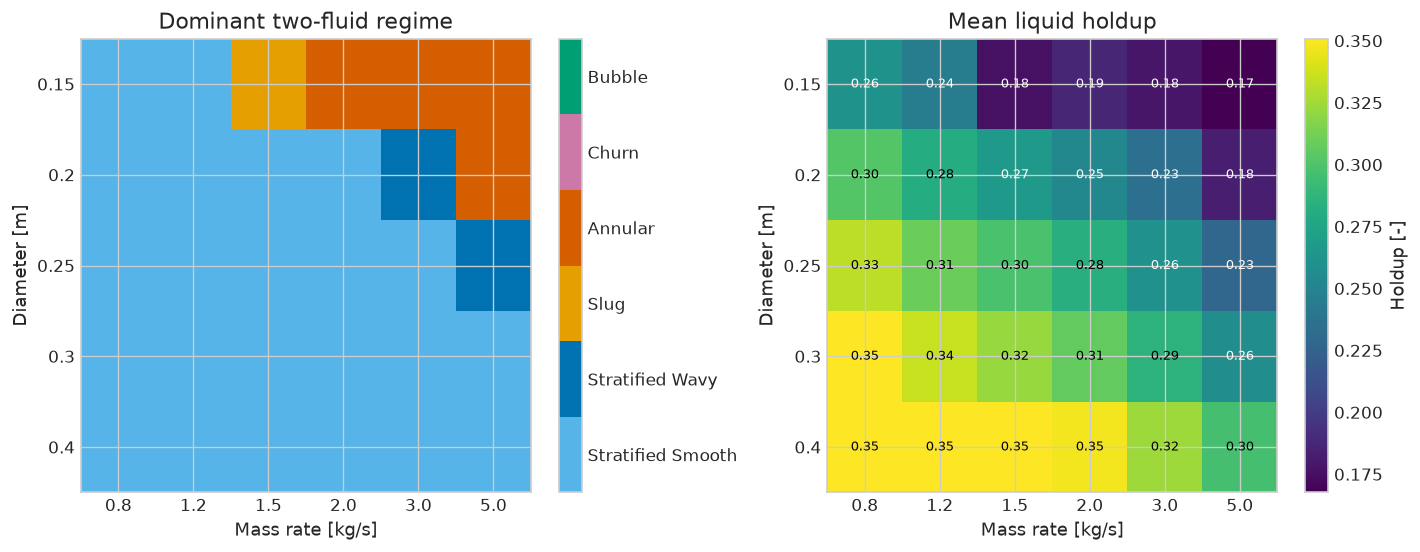

In [12]:
regime_order = [
    "STRATIFIED_SMOOTH",
    "STRATIFIED_WAVY",
    "SLUG",
    "ANNULAR",
    "CHURN",
    "BUBBLE",
]
regime_code = {
    regime: index
    for index, regime in enumerate(regime_order)
}

regime_grid = np.zeros(
    (len(diameters_m), len(rates_kg_s)),
    dtype=int,
)
holdup_grid = np.zeros_like(regime_grid, dtype=float)

for row_index, diameter_m in enumerate(diameters_m):
    for column_index, rate_kg_s in enumerate(rates_kg_s):
        match = screen_table[
            np.isclose(screen_table["diameter [m]"], diameter_m)
            & np.isclose(screen_table["rate [kg/s]"], rate_kg_s)
        ].iloc[0]
        regime_grid[row_index, column_index] = regime_code.get(
            match["dominant regime"],
            len(regime_order) - 1,
        )
        holdup_grid[row_index, column_index] = match[
            "mean holdup [-]"
        ]

colors = [
    "#56B4E9",
    "#0072B2",
    "#E69F00",
    "#D55E00",
    "#CC79A7",
    "#009E73",
]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.7))

regime_image = axes[0].imshow(
    regime_grid,
    aspect="auto",
    cmap=ListedColormap(colors),
    vmin=-0.5,
    vmax=len(regime_order) - 0.5,
)
axes[0].set(
    xticks=np.arange(len(rates_kg_s)),
    xticklabels=rates_kg_s,
    yticks=np.arange(len(diameters_m)),
    yticklabels=diameters_m,
    xlabel="Mass rate [kg/s]",
    ylabel="Diameter [m]",
    title="Dominant two-fluid regime",
)
colorbar = fig.colorbar(
    regime_image,
    ax=axes[0],
    ticks=np.arange(len(regime_order)),
)
colorbar.ax.set_yticklabels(
    [value.replace("_", " ").title() for value in regime_order]
)

holdup_image = axes[1].imshow(
    holdup_grid,
    aspect="auto",
    cmap="viridis",
)
axes[1].set(
    xticks=np.arange(len(rates_kg_s)),
    xticklabels=rates_kg_s,
    yticks=np.arange(len(diameters_m)),
    yticklabels=diameters_m,
    xlabel="Mass rate [kg/s]",
    ylabel="Diameter [m]",
    title="Mean liquid holdup",
)
fig.colorbar(holdup_image, ax=axes[1], label="Holdup [-]")

for row_index in range(len(diameters_m)):
    for column_index in range(len(rates_kg_s)):
        axes[1].text(
            column_index,
            row_index,
            f"{holdup_grid[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            color=(
                "black"
                if holdup_grid[row_index, column_index] > 0.27
                else "white"
            ),
            fontsize=8,
        )

fig.tight_layout()
plt.show()

The 0.15 m, 1.5 kg/s base point lies in the predicted slug region. Increasing rate in that
small diameter moves the case toward annular flow, while larger diameters at the same rate
favor stratification. These transitions are physically plausible screening trends.

## Transient rate sequence

The two-fluid pipe is initialized at 1.5 kg/s and then receives four deterministic periods:

1. base rate, 1.5 kg/s;
2. increased rate, 2.5 kg/s;
3. turndown, 0.8 kg/s; and
4. recovery, 1.5 kg/s.

The outlet pressure from the initialized state is retained as the downstream boundary.
Consequently the inlet and internal pressures respond while the outlet pressure remains
fixed. The Lagrangian slug-unit overlay is disabled; this isolates the conservative
two-fluid hydraulic response.

In [13]:
transient_feed, transient_pipe = run_two_fluid_case(
    "Two-fluid transient",
    case_fluid,
    BASE_RATE_KG_S,
    BASE_DIAMETER_M,
    BASE_LENGTH_M,
    24,
)


def scheduled_rate(step_index):
    if step_index < 25:
        return 1.5
    if step_index < 70:
        return 2.5
    if step_index < 115:
        return 0.8
    return 1.5


transient_rows = []
holdup_snapshots = {}
snapshot_steps = [0, 25, 70, 115, 150]

for step_index in range(151):
    rate_kg_s = scheduled_rate(step_index)
    transient_feed.setFlowRate(rate_kg_s, "kg/sec")
    transient_feed.run()
    transient_pipe.runTransient(
        1.0,
        JavaUUID.randomUUID(),
    )

    pressure_bar = (
        np.asarray(transient_pipe.getPressureProfile()) / 1.0e5
    )
    holdup = np.asarray(
        transient_pipe.getLiquidHoldupProfile()
    )
    gas_velocity_m_s = np.asarray(
        transient_pipe.getGasVelocityProfile()
    )
    liquid_velocity_m_s = np.asarray(
        transient_pipe.getLiquidVelocityProfile()
    )

    transient_rows.append(
        {
            "time [s]": transient_pipe.getSimulationTime(),
            "rate [kg/s]": rate_kg_s,
            "inlet pressure [bara]": pressure_bar[0],
            "mid pressure [bara]": pressure_bar[
                len(pressure_bar) // 2
            ],
            "outlet pressure [bara]": pressure_bar[-1],
            "mean holdup [-]": holdup.mean(),
            "liquid inventory [m³]": (
                transient_pipe.getLiquidInventory("m3")
            ),
            "minimum gas velocity [m/s]": (
                gas_velocity_m_s.min()
            ),
            "minimum liquid velocity [m/s]": (
                liquid_velocity_m_s.min()
            ),
            "maximum holdup [-]": holdup.max(),
        }
    )

    if step_index in snapshot_steps:
        holdup_snapshots[step_index] = holdup.copy()

transient_table = pd.DataFrame(transient_rows)
display(transient_table.iloc[[0, 24, 25, 69, 70, 114, 115, 150]])

,time [s],rate [kg/s],inlet pressure [bara],mid pressure [bara],outlet pressure [bara],mean holdup [-],liquid inventory [m³],minimum gas velocity [m/s],minimum liquid velocity [m/s],maximum holdup [-]
0,1.0,1.5,50.002074,49.972964,49.940428,0.159657,1.692820,1.246116,0.211445,0.169583
24,25.0,1.5,50.004468,49.973351,49.940428,0.173025,1.834561,1.247077,0.174427,0.221682
25,26.0,2.5,50.109882,50.028909,49.940428,0.170395,1.806677,2.081546,0.299649,0.215025
69,70.0,2.5,50.103674,50.026800,49.940428,0.170213,1.804748,2.082793,0.349920,0.188029
70,71.0,0.8,49.959974,49.950574,49.940428,0.175975,1.865836,0.669474,0.082455,0.247460
114,115.0,0.8,49.960367,49.950550,49.940428,0.188557,1.999246,0.677896,0.091858,0.227461
115,116.0,1.5,50.007450,49.974859,49.940428,0.184744,1.958821,1.267282,0.178741,0.217405
150,151.0,1.5,50.004594,49.973275,49.940428,0.172091,1.824664,1.251399,0.176356,0.219351


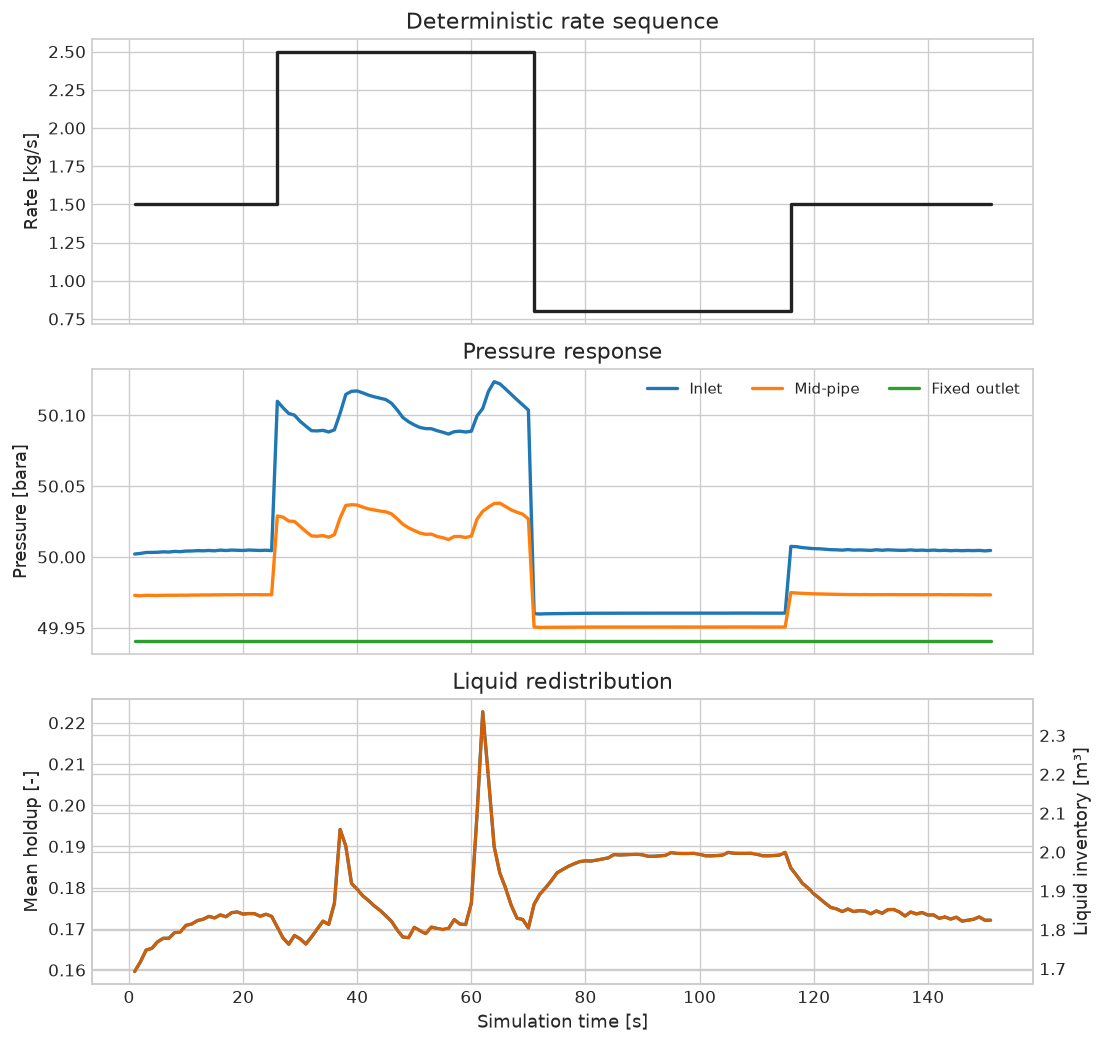

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(9.3, 8.8), sharex=True)

axes[0].step(
    transient_table["time [s]"],
    transient_table["rate [kg/s]"],
    where="post",
    color="#222222",
    lw=2.0,
)
axes[0].set(ylabel="Rate [kg/s]", title="Deterministic rate sequence")

axes[1].plot(
    transient_table["time [s]"],
    transient_table["inlet pressure [bara]"],
    lw=2.0,
    label="Inlet",
)
axes[1].plot(
    transient_table["time [s]"],
    transient_table["mid pressure [bara]"],
    lw=2.0,
    label="Mid-pipe",
)
axes[1].plot(
    transient_table["time [s]"],
    transient_table["outlet pressure [bara]"],
    lw=2.0,
    label="Fixed outlet",
)
axes[1].set(ylabel="Pressure [bara]", title="Pressure response")
axes[1].legend(ncol=3)

axes[2].plot(
    transient_table["time [s]"],
    transient_table["mean holdup [-]"],
    lw=2.0,
    label="Mean holdup",
)
inventory_axis = axes[2].twinx()
inventory_axis.plot(
    transient_table["time [s]"],
    transient_table["liquid inventory [m³]"],
    color="#D55E00",
    lw=1.8,
    label="Liquid inventory",
)
axes[2].set(
    xlabel="Simulation time [s]",
    ylabel="Mean holdup [-]",
    title="Liquid redistribution",
)
inventory_axis.set_ylabel("Liquid inventory [m³]")

fig.tight_layout()
plt.show()

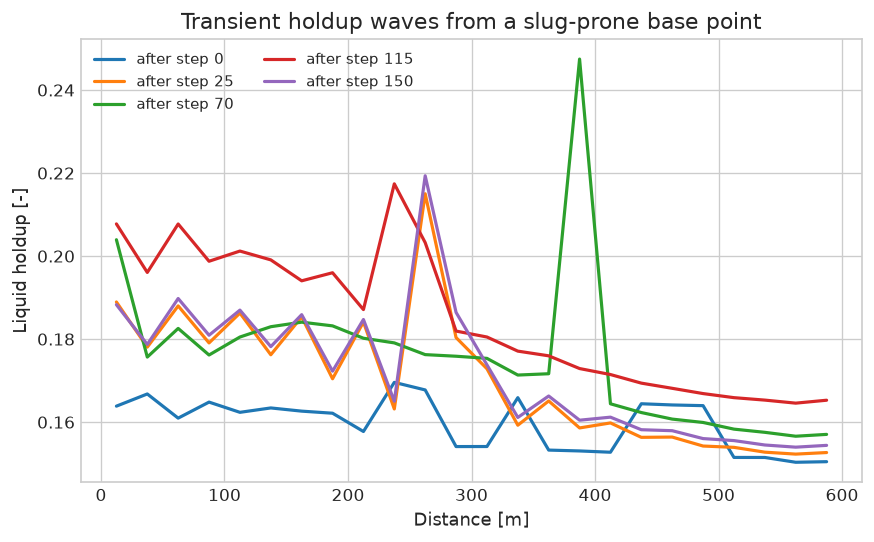

In [15]:
transient_x_m = np.asarray(
    transient_pipe.getPositionProfile()
)
fig, axis = plt.subplots()

for snapshot_step in snapshot_steps:
    axis.plot(
        transient_x_m,
        holdup_snapshots[snapshot_step],
        lw=1.9,
        label=f"after step {snapshot_step}",
    )

axis.set(
    xlabel="Distance [m]",
    ylabel="Liquid holdup [-]",
    title="Transient holdup waves from a slug-prone base point",
)
axis.legend(ncol=2)
plt.show()

The pressure response follows the imposed rate: higher flow requires higher upstream
pressure against the fixed outlet, while turndown reduces it. Gas and liquid velocities
remain downstream-directed. The holdup snapshots show liquid redistribution without
unphysical negative or greater-than-one fractions.

The steady operating map—not a single transient cell label—is used to identify the
slug-prone region. This avoids interpreting numerical cell-to-cell regime switching as a
measured slug frequency.

## Oil and gas wellstream in an S-riser

This second application uses a richer oil-and-gas wellstream and a four-leg S-profile:

1. a 600 m horizontal flowline;
2. a 300 m rise to a buoyant arch;
3. a 300 m descent to the sag bend; and
4. a 500 m production riser to the topside.

Distance $s$ follows the pipe centerline and elevation $z$ is relative to the subsea
inlet. For each leg,

$$
\sin\theta_i=\frac{\Delta z_i}{\Delta s_i}
$$

and the hydrostatic contribution is screened independently with

$$
\Delta p_g=\int \rho_m g\,dz
$$

`PipeBeggsAndBrills` accepts one net elevation per calculation, so four connected Beggs–
Brill pipes preserve the arch and sag. `TwoFluidPipe` receives the complete elevation
profile in one integrated model. Both use the same fluid, 0.20 m internal diameter,
45 µm roughness, 1,700 m centerline length, and 15 kg/s inlet rate.

In [16]:
s_riser_composition = {
    "methane": 0.60,
    "ethane": 0.08,
    "propane": 0.06,
    "i-butane": 0.03,
    "n-butane": 0.04,
    "n-pentane": 0.04,
    "n-hexane": 0.03,
    "n-heptane": 0.05,
    "nC10": 0.04,
    "water": 0.03,
}

s_riser_fluid = fluid("srk")
for component, fraction in s_riser_composition.items():
    s_riser_fluid.addComponent(component, fraction)

s_riser_fluid.setMixingRule(2)
s_riser_fluid.setMultiPhaseCheck(True)
s_riser_fluid.setTemperature(35.0, "C")
s_riser_fluid.setPressure(75.0, "bara")
TPflash(s_riser_fluid)
s_riser_fluid.initPhysicalProperties()

s_riser_phase_rows = []
for phase_index in range(s_riser_fluid.getNumberOfPhases()):
    phase = s_riser_fluid.getPhase(phase_index)
    s_riser_phase_rows.append(
        {
            "phase": str(phase.getPhaseTypeName()),
            "mole split": s_riser_fluid.getBeta(phase_index),
            "density [kg/m³]": phase.getDensity("kg/m3"),
        }
    )

s_riser_phase_table = pd.DataFrame(s_riser_phase_rows)
display(s_riser_phase_table.round(5))

,phase,mole split,density [kg/m³]
0,gas,0.56491,70.21372
1,oil,0.40608,555.67438
2,aqueous,0.02902,993.89336


,leg,length [m],elevation change [m],inclination [degree]
0,Flowline,600.0,0.0,0.000
1,Arch rise,300.0,80.0,15.466
2,Sag descent,300.0,-100.0,-19.471
3,Topside riser,500.0,240.0,28.685


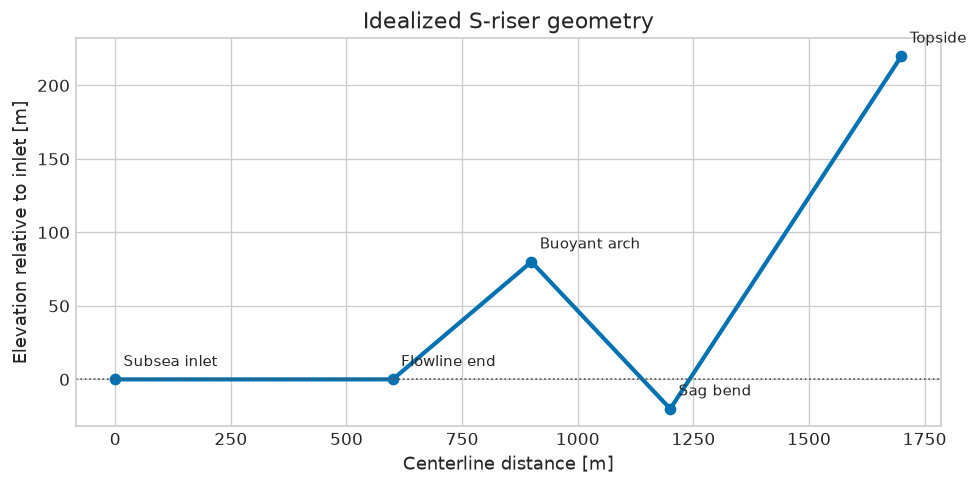

In [17]:
S_RISER_RATE_KG_S = 15.0
S_RISER_DIAMETER_M = 0.20
S_RISER_ROUGHNESS_M = 4.5e-5
S_RISER_TEMPERATURE_C = 35.0
S_RISER_PRESSURE_BARA = 75.0

s_riser_node_distance_m = np.array(
    [0.0, 600.0, 900.0, 1200.0, 1700.0]
)
s_riser_node_elevation_m = np.array(
    [0.0, 0.0, 80.0, -20.0, 220.0]
)
s_riser_leg_names = [
    "Flowline",
    "Arch rise",
    "Sag descent",
    "Topside riser",
]
s_riser_leg_lengths_m = np.diff(s_riser_node_distance_m)
s_riser_leg_elevations_m = np.diff(
    s_riser_node_elevation_m
)
s_riser_leg_increments = [14, 10, 10, 16]
s_riser_leg_angles_deg = np.degrees(
    np.arcsin(
        s_riser_leg_elevations_m
        / s_riser_leg_lengths_m
    )
)

s_riser_geometry_table = pd.DataFrame(
    {
        "leg": s_riser_leg_names,
        "length [m]": s_riser_leg_lengths_m,
        "elevation change [m]": s_riser_leg_elevations_m,
        "inclination [degree]": s_riser_leg_angles_deg,
    }
)
display(s_riser_geometry_table.round(3))

fig, axis = plt.subplots(figsize=(9.3, 4.2))
axis.plot(
    s_riser_node_distance_m,
    s_riser_node_elevation_m,
    marker="o",
    lw=2.5,
    color="#0072B2",
)

for node_index, (distance_m, elevation_m) in enumerate(
    zip(
        s_riser_node_distance_m,
        s_riser_node_elevation_m,
    )
):
    labels = [
        "Subsea inlet",
        "Flowline end",
        "Buoyant arch",
        "Sag bend",
        "Topside",
    ]
    axis.annotate(
        labels[node_index],
        (distance_m, elevation_m),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=9,
    )

axis.axhline(0.0, color="#555555", lw=1.0, ls=":")
axis.set(
    xlabel="Centerline distance [m]",
    ylabel="Elevation relative to inlet [m]",
    title="Idealized S-riser geometry",
)
plt.show()

In [18]:
def build_s_riser_stream(name, source_fluid, mass_rate_kg_s):
    stream = jneqsim.process.equipment.stream.Stream(
        name,
        source_fluid.clone(),
    )
    stream.setFlowRate(mass_rate_kg_s, "kg/sec")
    stream.setTemperature(S_RISER_TEMPERATURE_C, "C")
    stream.setPressure(S_RISER_PRESSURE_BARA, "bara")
    stream.run()
    return stream


def run_beggs_s_riser(source_fluid, mass_rate_kg_s):
    feed = build_s_riser_stream(
        "Beggs S-riser feed",
        source_fluid,
        mass_rate_kg_s,
    )
    current_stream = feed
    pipes = []
    distance_parts = []
    elevation_parts = []
    pressure_parts = []
    holdup_parts = []
    density_parts = []
    regimes = []

    leg_inputs = zip(
        s_riser_leg_lengths_m,
        s_riser_leg_elevations_m,
        s_riser_leg_increments,
    )
    for leg_index, values in enumerate(leg_inputs):
        length_m, elevation_m, increments = values
        pipe = (
            jneqsim.process.equipment.pipeline
            .PipeBeggsAndBrills(
                f"Beggs S-riser leg {leg_index + 1}",
                current_stream,
            )
        )
        pipe.setLength(float(length_m))
        pipe.setElevation(float(elevation_m))
        pipe.setDiameter(S_RISER_DIAMETER_M)
        pipe.setPipeWallRoughness(S_RISER_ROUGHNESS_M)
        pipe.setNumberOfIncrements(increments)
        pipe.setRunIsothermal(True)
        pipe.run()

        local_pressure = np.asarray(pipe.getPressureProfile())
        local_points = len(local_pressure)
        local_distance = np.linspace(
            s_riser_node_distance_m[leg_index],
            s_riser_node_distance_m[leg_index + 1],
            local_points,
        )
        local_elevation = np.linspace(
            s_riser_node_elevation_m[leg_index],
            s_riser_node_elevation_m[leg_index + 1],
            local_points,
        )
        local_holdup = np.asarray(
            pipe.getLiquidHoldupProfile()
        )
        local_density = np.asarray(
            pipe.getMixtureDensityProfile()
        )

        if leg_index > 0:
            local_pressure = local_pressure[1:]
            local_distance = local_distance[1:]
            local_elevation = local_elevation[1:]
            local_holdup = local_holdup[1:]
            local_density = local_density[1:]

        distance_parts.append(local_distance)
        elevation_parts.append(local_elevation)
        pressure_parts.append(local_pressure)
        holdup_parts.append(local_holdup)
        density_parts.append(local_density)
        regimes.extend(
            str(value)
            for value in pipe.getFlowRegimeProfileList()
        )
        pipes.append(pipe)
        current_stream = pipe.getOutletStream()

    results = {
        "feed": feed,
        "pipes": pipes,
        "outlet": current_stream,
        "distance_m": np.concatenate(distance_parts),
        "elevation_m": np.concatenate(elevation_parts),
        "pressure_bar": np.concatenate(pressure_parts),
        "holdup": np.concatenate(holdup_parts),
        "density_kg_m3": np.concatenate(density_parts),
        "regimes": regimes,
    }
    return results


def run_two_fluid_s_riser(source_fluid, mass_rate_kg_s):
    feed = build_s_riser_stream(
        "Two-fluid S-riser feed",
        source_fluid,
        mass_rate_kg_s,
    )
    pipe = jneqsim.process.equipment.pipeline.TwoFluidPipe(
        "Integrated two-fluid S-riser",
        feed,
    )
    sections = 50
    geometry_distance_m = np.linspace(
        s_riser_node_distance_m[0],
        s_riser_node_distance_m[-1],
        sections,
    )
    geometry_elevation_m = np.interp(
        geometry_distance_m,
        s_riser_node_distance_m,
        s_riser_node_elevation_m,
    )
    pipe.setLength(float(s_riser_node_distance_m[-1]))
    pipe.setDiameter(S_RISER_DIAMETER_M)
    pipe.setRoughness(S_RISER_ROUGHNESS_M)
    pipe.setNumberOfSections(sections)
    pipe.setElevationProfile(geometry_elevation_m.tolist())
    pipe.setThermodynamicUpdateInterval(10)
    pipe.setSteadyStateFlashInterval(10)
    pipe.setSteadyStateMaxWallClockTime(30.0)
    pipe.run()
    return feed, pipe

### Steady S-riser comparison

The models are not tuned to each other. Pressure is allowed to rise through the descending
sag leg when hydrostatic recovery exceeds friction. The full-riser outlet discrepancy is
reported as model-form uncertainty.

In [19]:
s_riser_beggs = run_beggs_s_riser(
    s_riser_fluid,
    S_RISER_RATE_KG_S,
)
s_riser_two_feed, s_riser_two_pipe = run_two_fluid_s_riser(
    s_riser_fluid,
    S_RISER_RATE_KG_S,
)

s_riser_beggs_x_m = s_riser_beggs["distance_m"]
s_riser_beggs_z_m = s_riser_beggs["elevation_m"]
s_riser_beggs_pressure_bar = s_riser_beggs[
    "pressure_bar"
]
s_riser_beggs_holdup = s_riser_beggs["holdup"]
s_riser_beggs_density_kg_m3 = s_riser_beggs[
    "density_kg_m3"
]

s_riser_two_x_m = np.asarray(
    s_riser_two_pipe.getPositionProfile()
)
s_riser_two_z_m = np.interp(
    s_riser_two_x_m,
    s_riser_node_distance_m,
    s_riser_node_elevation_m,
)
s_riser_two_pressure_bar = (
    np.asarray(s_riser_two_pipe.getPressureProfile())
    / 1.0e5
)
s_riser_two_holdup = np.asarray(
    s_riser_two_pipe.getLiquidHoldupProfile()
)
s_riser_two_gas_velocity_m_s = np.asarray(
    s_riser_two_pipe.getGasVelocityProfile()
)
s_riser_two_liquid_velocity_m_s = np.asarray(
    s_riser_two_pipe.getLiquidVelocityProfile()
)
s_riser_two_regimes = [
    str(value)
    for value in s_riser_two_pipe.getFlowRegimeProfile()
]

s_riser_beggs_dp_bar = (
    s_riser_beggs_pressure_bar[0]
    - s_riser_beggs_pressure_bar[-1]
)
s_riser_two_dp_bar = (
    s_riser_two_pressure_bar[0]
    - s_riser_two_pressure_bar[-1]
)
s_riser_dp_difference = (
    abs(s_riser_two_dp_bar - s_riser_beggs_dp_bar)
    / s_riser_beggs_dp_bar
)
s_riser_beggs_hydrostatic_bar = np.sum(
    0.5
    * (
        s_riser_beggs_density_kg_m3[:-1]
        + s_riser_beggs_density_kg_m3[1:]
    )
    * 9.80665
    * np.diff(s_riser_beggs_z_m)
) / 1.0e5
s_riser_mass_residual_kg_s = abs(
    s_riser_two_feed.getFlowRate("kg/sec")
    - s_riser_two_pipe.getOutletStream().getFlowRate(
        "kg/sec"
    )
)

s_riser_beggs_node_pressure_bar = np.interp(
    s_riser_node_distance_m,
    s_riser_beggs_x_m,
    s_riser_beggs_pressure_bar,
)
s_riser_two_node_pressure_bar = np.interp(
    s_riser_node_distance_m,
    s_riser_two_x_m,
    s_riser_two_pressure_bar,
)

In [20]:
s_riser_summary = pd.DataFrame(
    [
        {
            "model": "Connected Beggs–Brill legs",
            "outlet pressure [bara]": (
                s_riser_beggs_pressure_bar[-1]
            ),
            "pressure drop [bar]": s_riser_beggs_dp_bar,
            "mean holdup [-]": s_riser_beggs_holdup.mean(),
            "regime(s)": ", ".join(
                sorted(set(s_riser_beggs["regimes"]))
            ),
        },
        {
            "model": "Integrated two-fluid",
            "outlet pressure [bara]": (
                s_riser_two_pressure_bar[-1]
            ),
            "pressure drop [bar]": s_riser_two_dp_bar,
            "mean holdup [-]": s_riser_two_holdup.mean(),
            "regime(s)": ", ".join(
                sorted(set(s_riser_two_regimes))
            ),
        },
    ]
)
display(s_riser_summary.round(6))

print(
    "Beggs–Brill hydrostatic screening contribution: "
    f"{s_riser_beggs_hydrostatic_bar:.6f} bar"
)
print(
    "Relative S-riser pressure-drop difference: "
    f"{s_riser_dp_difference:.3%}"
)
print(
    "Two-fluid S-riser mass-flow residual: "
    f"{s_riser_mass_residual_kg_s:.3e} kg/s"
)

Beggs–Brill hydrostatic screening contribution: 3.582372 bar
Relative S-riser pressure-drop difference: 129.618%
Two-fluid S-riser mass-flow residual: 0.000e+00 kg/s


,model,outlet pressure [bara],pressure drop [bar],mean holdup [-],regime(s)
0,Connected Beggs–Brill legs,68.544947,6.455053,0.353621,INTERMITTENT
1,Integrated two-fluid,60.178008,14.821992,0.414062,"ANNULAR, CHURN, SLUG, STRATIFIED_SMOOTH"


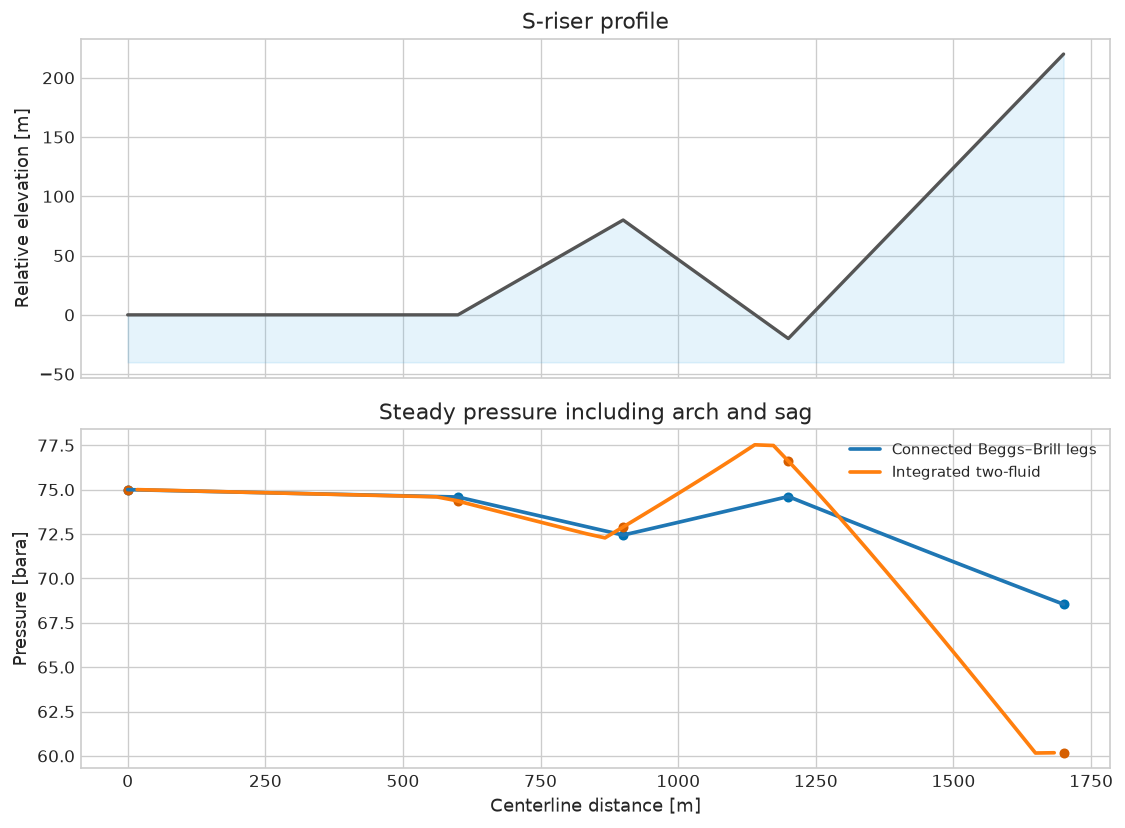

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 7.0), sharex=True)

axes[0].plot(
    s_riser_beggs_x_m,
    s_riser_beggs_z_m,
    color="#555555",
    lw=2.0,
)
axes[0].fill_between(
    s_riser_beggs_x_m,
    s_riser_beggs_z_m,
    s_riser_beggs_z_m.min() - 20.0,
    color="#56B4E9",
    alpha=0.15,
)
axes[0].set(
    ylabel="Relative elevation [m]",
    title="S-riser profile",
)

axes[1].plot(
    s_riser_beggs_x_m,
    s_riser_beggs_pressure_bar,
    lw=2.2,
    label="Connected Beggs–Brill legs",
)
axes[1].plot(
    s_riser_two_x_m,
    s_riser_two_pressure_bar,
    lw=2.2,
    label="Integrated two-fluid",
)
axes[1].scatter(
    s_riser_node_distance_m,
    s_riser_beggs_node_pressure_bar,
    s=25,
    color="#0072B2",
)
axes[1].scatter(
    s_riser_node_distance_m,
    s_riser_two_node_pressure_bar,
    s=25,
    color="#D55E00",
)
axes[1].set(
    xlabel="Centerline distance [m]",
    ylabel="Pressure [bara]",
    title="Steady pressure including arch and sag",
)
axes[1].legend()

fig.tight_layout()
plt.show()

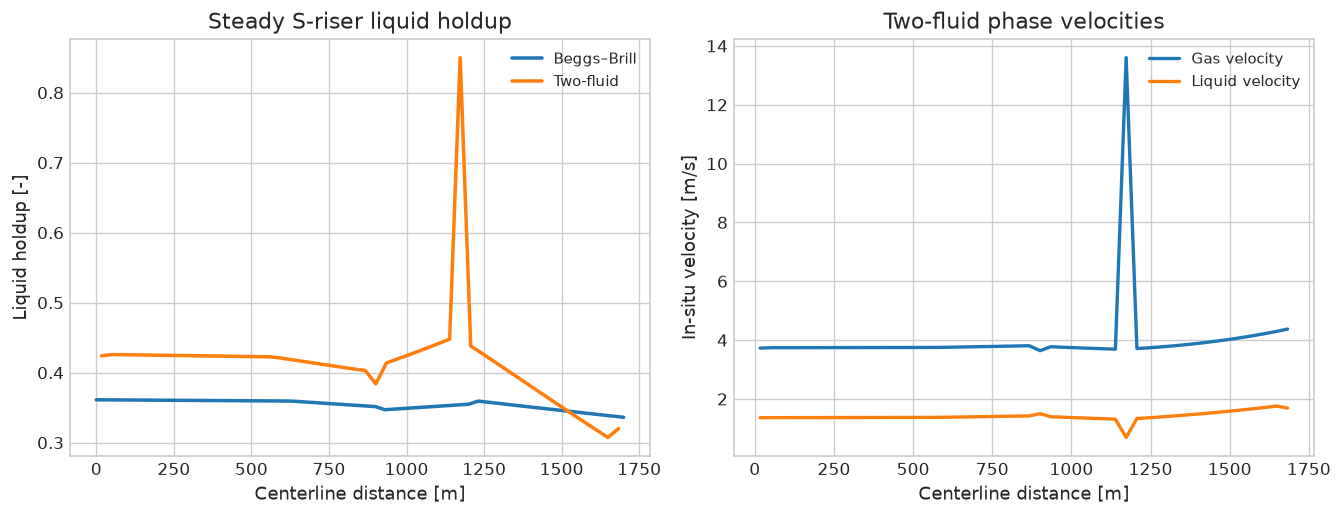

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11.3, 4.4))

axes[0].plot(
    s_riser_beggs_x_m,
    s_riser_beggs_holdup,
    lw=2.1,
    label="Beggs–Brill",
)
axes[0].plot(
    s_riser_two_x_m,
    s_riser_two_holdup,
    lw=2.1,
    label="Two-fluid",
)
axes[0].set(
    xlabel="Centerline distance [m]",
    ylabel="Liquid holdup [-]",
    title="Steady S-riser liquid holdup",
)
axes[0].legend()

axes[1].plot(
    s_riser_two_x_m,
    s_riser_two_gas_velocity_m_s,
    lw=2.0,
    label="Gas velocity",
)
axes[1].plot(
    s_riser_two_x_m,
    s_riser_two_liquid_velocity_m_s,
    lw=2.0,
    label="Liquid velocity",
)
axes[1].set(
    xlabel="Centerline distance [m]",
    ylabel="In-situ velocity [m/s]",
    title="Two-fluid phase velocities",
)
axes[1].legend()

fig.tight_layout()
plt.show()

Both models recover pressure through the descending arch-to-sag leg. The two-fluid model
predicts substantially more liquid retention and a larger full-riser pressure requirement.
That discrepancy is useful: an S-riser design should not silently inherit one correlation
without comparison to relevant field, loop, or higher-fidelity transient data.

### S-riser turndown transient

After a 30 s conditioning period at 15 kg/s, the wellstream is reduced to 7.5 kg/s for
90 s and then restored. The initialized two-fluid outlet pressure is retained as the
downstream boundary. A 0.5 s time step is used because a 1.0 s sensitivity run produced
alternating sag-cell values; those grid-scale oscillations must not be interpreted as a
physical slug frequency. The calculation tracks total liquid inventory and mean holdup
around the sag bend, but does not claim a calibrated individual-slug arrival distribution.

In [23]:
s_riser_transient_rows = []
s_riser_holdup_snapshots = {}
s_riser_time_step_s = 0.5
s_riser_snapshot_steps = [0, 60, 150, 240, 361]
s_riser_sag_mask = (
    (s_riser_two_x_m >= 1080.0)
    & (s_riser_two_x_m <= 1320.0)
)

for step_index in range(362):
    if step_index < 60:
        rate_kg_s = 15.0
    elif step_index < 240:
        rate_kg_s = 7.5
    else:
        rate_kg_s = 15.0

    s_riser_two_feed.setFlowRate(rate_kg_s, "kg/sec")
    s_riser_two_feed.run()
    s_riser_two_pipe.runTransient(
        s_riser_time_step_s,
        JavaUUID.randomUUID(),
    )

    pressure_bar = (
        np.asarray(s_riser_two_pipe.getPressureProfile())
        / 1.0e5
    )
    holdup = np.asarray(
        s_riser_two_pipe.getLiquidHoldupProfile()
    )
    gas_velocity_m_s = np.asarray(
        s_riser_two_pipe.getGasVelocityProfile()
    )
    liquid_velocity_m_s = np.asarray(
        s_riser_two_pipe.getLiquidVelocityProfile()
    )

    s_riser_transient_rows.append(
        {
            "time [s]": s_riser_two_pipe.getSimulationTime(),
            "rate [kg/s]": rate_kg_s,
            "inlet pressure [bara]": pressure_bar[0],
            "outlet pressure [bara]": pressure_bar[-1],
            "liquid inventory [m³]": (
                s_riser_two_pipe.getLiquidInventory("m3")
            ),
            "sag holdup [-]": holdup[
                s_riser_sag_mask
            ].mean(),
            "maximum holdup [-]": holdup.max(),
            "minimum gas velocity [m/s]": (
                gas_velocity_m_s.min()
            ),
            "minimum liquid velocity [m/s]": (
                liquid_velocity_m_s.min()
            ),
        }
    )

    if step_index in s_riser_snapshot_steps:
        s_riser_holdup_snapshots[step_index] = (
            holdup.copy()
        )

s_riser_transient_table = pd.DataFrame(
    s_riser_transient_rows
)
display(
    s_riser_transient_table.iloc[
        [0, 59, 60, 150, 239, 240, 300, 361]
    ].round(6)
)

,time [s],rate [kg/s],inlet pressure [bara],outlet pressure [bara],liquid inventory [m³],sag holdup [-],maximum holdup [-],minimum gas velocity [m/s],minimum liquid velocity [m/s]
0,0.5,15.0,77.233731,60.178008,33.929583,0.916113,0.93825,3.238591,0.401786
59,30.0,15.0,77.986890,60.178008,38.113673,0.914103,0.93825,3.735739,0.362656
60,30.5,7.5,76.239453,60.178008,38.025429,0.915096,0.93825,1.892373,0.181331
150,75.5,7.5,76.847508,60.178008,39.239535,0.914643,0.93825,1.768435,0.179167
239,120.0,7.5,76.880022,60.178008,39.419553,0.914634,0.93825,1.753148,0.179163
240,120.5,15.0,77.361389,60.178008,39.090545,0.913700,0.93825,3.509096,0.358334
300,150.5,15.0,77.848585,60.178008,38.089766,0.914046,0.93825,3.722714,0.362645
361,181.0,15.0,77.861476,60.178008,37.984867,0.914050,0.93825,3.754797,0.362645


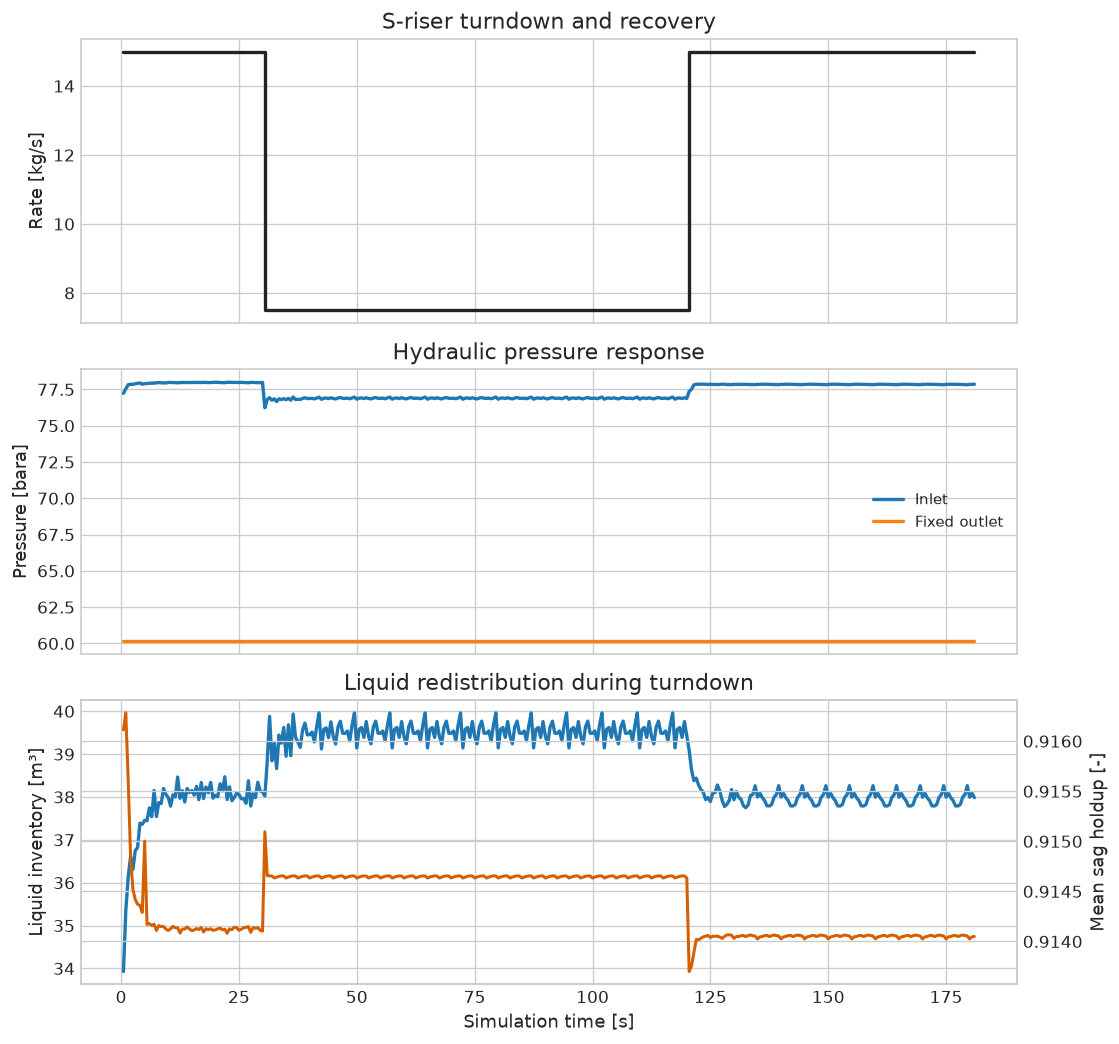

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(9.3, 8.8), sharex=True)

axes[0].step(
    s_riser_transient_table["time [s]"],
    s_riser_transient_table["rate [kg/s]"],
    where="post",
    color="#222222",
    lw=2.0,
)
axes[0].set(
    ylabel="Rate [kg/s]",
    title="S-riser turndown and recovery",
)

axes[1].plot(
    s_riser_transient_table["time [s]"],
    s_riser_transient_table["inlet pressure [bara]"],
    lw=2.0,
    label="Inlet",
)
axes[1].plot(
    s_riser_transient_table["time [s]"],
    s_riser_transient_table["outlet pressure [bara]"],
    lw=2.0,
    label="Fixed outlet",
)
axes[1].set(
    ylabel="Pressure [bara]",
    title="Hydraulic pressure response",
)
axes[1].legend()

axes[2].plot(
    s_riser_transient_table["time [s]"],
    s_riser_transient_table["liquid inventory [m³]"],
    lw=2.0,
    label="Total inventory",
)
sag_axis = axes[2].twinx()
sag_axis.plot(
    s_riser_transient_table["time [s]"],
    s_riser_transient_table["sag holdup [-]"],
    color="#D55E00",
    lw=1.8,
    label="Sag holdup",
)
axes[2].set(
    xlabel="Simulation time [s]",
    ylabel="Liquid inventory [m³]",
    title="Liquid redistribution during turndown",
)
sag_axis.set_ylabel("Mean sag holdup [-]")

fig.tight_layout()
plt.show()

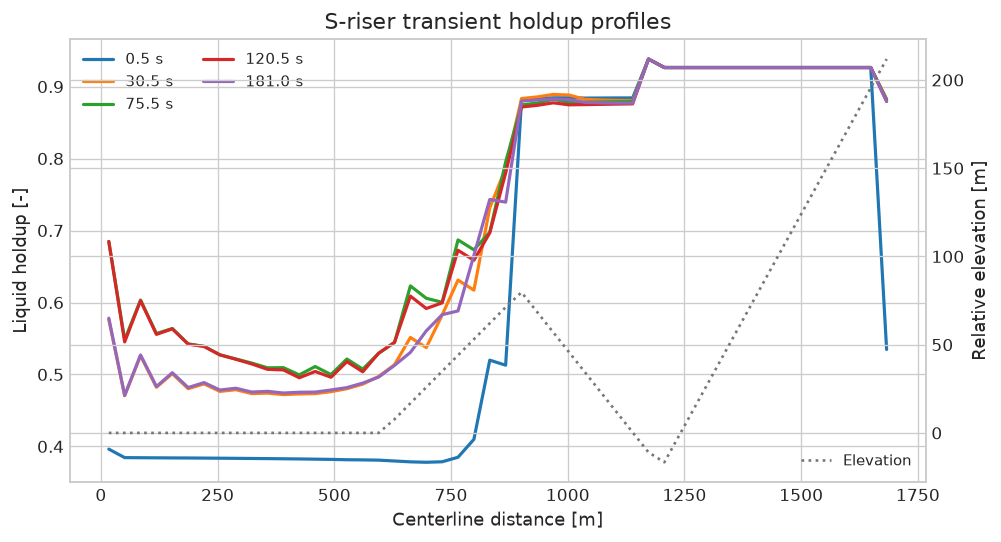

In [25]:
fig, axis = plt.subplots(figsize=(9.2, 4.8))

for snapshot_step in s_riser_snapshot_steps:
    snapshot_time_s = s_riser_transient_table.iloc[
        snapshot_step
    ]["time [s]"]
    axis.plot(
        s_riser_two_x_m,
        s_riser_holdup_snapshots[snapshot_step],
        lw=1.9,
        label=f"{snapshot_time_s:.1f} s",
    )

elevation_axis = axis.twinx()
elevation_axis.plot(
    s_riser_two_x_m,
    s_riser_two_z_m,
    color="#777777",
    ls=":",
    lw=1.6,
    label="Elevation",
)
axis.set(
    xlabel="Centerline distance [m]",
    ylabel="Liquid holdup [-]",
    title="S-riser transient holdup profiles",
)
elevation_axis.set_ylabel("Relative elevation [m]")
axis.legend(ncol=2, loc="upper left")
elevation_axis.legend(loc="lower right")
plt.show()

Turndown reduces phase velocities and raises total liquid inventory before recovery. The
sag and upper-riser cells remain liquid-rich, which is consistent with a slug-prone S-riser
screen. The values are bounded and downstream-directed, but must be calibrated before
using them for separator surge volume or fatigue design.

## Engineering validation

The checks below target numerical integrity and physical direction. They are deliberately
independent of exact stored values so the notebook remains useful across compatible NeqSim
patch releases.

In [26]:
base_window = transient_table.iloc[10:25]
high_window = transient_table.iloc[50:70]
low_window = transient_table.iloc[95:115]
recovery_window = transient_table.iloc[135:151]
pipe_internal_volume_m3 = (
    np.pi
    * BASE_DIAMETER_M**2
    / 4.0
    * BASE_LENGTH_M
)
s_riser_base_window = s_riser_transient_table.iloc[40:60]
s_riser_low_window = s_riser_transient_table.iloc[200:240]
s_riser_recovery_window = s_riser_transient_table.iloc[330:362]
s_riser_internal_volume_m3 = (
    np.pi
    * S_RISER_DIAMETER_M**2
    / 4.0
    * s_riser_node_distance_m[-1]
)


def regime_at(diameter_m, rate_kg_s):
    match = screen_table[
        np.isclose(screen_table["diameter [m]"], diameter_m)
        & np.isclose(screen_table["rate [kg/s]"], rate_kg_s)
    ]
    return match.iloc[0]["dominant regime"]


checks = {
    "multiphase inlet": case_fluid.getNumberOfPhases() >= 2,
    "Beggs pressure decreases": np.all(np.diff(beggs_pressure_bar) < 0),
    "two-fluid pressure decreases": np.all(np.diff(two_pressure_bar) < 0),
    "Beggs holdup bounded": np.all(
        (beggs_holdup > 0.0) & (beggs_holdup < 1.0)
    ),
    "two-fluid holdup bounded": np.all(
        (two_holdup > 0.0) & (two_holdup < 1.0)
    ),
    "two-fluid gas velocity positive": np.all(
        two_gas_velocity_m_s > 0.0
    ),
    "two-fluid liquid velocity positive": np.all(
        two_liquid_velocity_m_s > 0.0
    ),
    "steady mass flow closes": steady_mass_residual_kg_s < 1.0e-10,
    "Beggs pressure drop positive": beggs_dp_bar > 0.0,
    "two-fluid pressure drop positive": two_dp_bar > 0.0,
    "comparison finite": np.isfinite(relative_dp_difference),
    "base point is slug flow": (
        str(two_pipe.getDominantFlowRegime()) == "SLUG"
    ),
    "screen table complete": len(screen_table) == 30,
    "screen pressure drops positive": (
        screen_table["pressure drop [bar]"] > 0.0
    ).all(),
    "screen holdup bounded": (
        (screen_table["mean holdup [-]"] > 0.0)
        & (screen_table["mean holdup [-]"] < 1.0)
    ).all(),
    "small-pipe base remains slug": (
        regime_at(0.15, 1.5) == "SLUG"
    ),
    "small-pipe high rate is annular": (
        regime_at(0.15, 3.0) == "ANNULAR"
    ),
    "large-pipe low rate is stratified": (
        regime_at(0.40, 1.2) == "STRATIFIED_SMOOTH"
    ),
    "transient values finite": np.isfinite(
        transient_table.select_dtypes(include=[np.number])
    ).all().all(),
    "transient pressures positive": (
        transient_table[
            [
                "inlet pressure [bara]",
                "mid pressure [bara]",
                "outlet pressure [bara]",
            ]
        ] > 0.0
    ).all().all(),
    "transient holdup bounded": (
        (transient_table["mean holdup [-]"] > 0.0)
        & (transient_table["maximum holdup [-]"] < 1.0)
    ).all(),
    "gas remains downstream": (
        transient_table["minimum gas velocity [m/s]"] > 0.0
    ).all(),
    "liquid remains downstream": (
        transient_table["minimum liquid velocity [m/s]"] > 0.0
    ).all(),
    "high rate raises inlet pressure": (
        high_window["inlet pressure [bara]"].mean()
        > base_window["inlet pressure [bara]"].mean()
    ),
    "turndown lowers inlet pressure": (
        low_window["inlet pressure [bara]"].mean()
        < base_window["inlet pressure [bara]"].mean()
    ),
    "recovery returns toward base": abs(
        recovery_window["inlet pressure [bara]"].mean()
        - base_window["inlet pressure [bara]"].mean()
    ) < 0.02,
    "inventory remains bounded": (
        transient_table["liquid inventory [m³]"].max()
        - transient_table["liquid inventory [m³]"].min()
    ) < 0.10 * pipe_internal_volume_m3,
    "peak holdup remains plausible": (
        transient_table["maximum holdup [-]"].max() < 0.50
    ),
    "S-riser composition normalized": abs(
        sum(s_riser_composition.values()) - 1.0
    ) < 1.0e-12,
    "S-riser feed has three phases": (
        s_riser_fluid.getNumberOfPhases() == 3
    ),
    "S-riser distances increase": np.all(
        np.diff(s_riser_node_distance_m) > 0.0
    ),
    "S-riser inclinations plausible": np.all(
        np.abs(s_riser_leg_angles_deg) < 45.0
    ),
    "four connected Beggs legs": (
        len(s_riser_beggs["pipes"]) == 4
    ),
    "S-riser steady profiles finite": all(
        np.isfinite(values).all()
        for values in [
            s_riser_beggs_pressure_bar,
            s_riser_beggs_holdup,
            s_riser_two_pressure_bar,
            s_riser_two_holdup,
            s_riser_two_gas_velocity_m_s,
            s_riser_two_liquid_velocity_m_s,
        ]
    ),
    "S-riser steady pressures positive": (
        np.all(s_riser_beggs_pressure_bar > 0.0)
        and np.all(s_riser_two_pressure_bar > 0.0)
    ),
    "Beggs recovers pressure downhill": (
        s_riser_beggs_node_pressure_bar[3]
        > s_riser_beggs_node_pressure_bar[2]
    ),
    "two-fluid recovers pressure downhill": (
        s_riser_two_node_pressure_bar[3]
        > s_riser_two_node_pressure_bar[2]
    ),
    "S-riser pressure drops positive": (
        s_riser_beggs_dp_bar > 0.0
        and s_riser_two_dp_bar > 0.0
    ),
    "S-riser holdups bounded": (
        np.all(
            (s_riser_beggs_holdup > 0.0)
            & (s_riser_beggs_holdup < 1.0)
        )
        and np.all(
            (s_riser_two_holdup > 0.0)
            & (s_riser_two_holdup < 1.0)
        )
    ),
    "S-riser phase velocities positive": (
        np.all(s_riser_two_gas_velocity_m_s > 0.0)
        and np.all(s_riser_two_liquid_velocity_m_s > 0.0)
    ),
    "S-riser mass flow closes": (
        s_riser_mass_residual_kg_s < 1.0e-10
    ),
    "hydrostatic screening contribution positive": (
        0.0
        < s_riser_beggs_hydrostatic_bar
        < s_riser_beggs_dp_bar
    ),
    "S-riser model comparison finite": (
        np.isfinite(s_riser_dp_difference)
        and 0.25
        < s_riser_two_dp_bar / s_riser_beggs_dp_bar
        < 4.0
    ),
    "S-riser transient complete": (
        len(s_riser_transient_table) == 362
    ),
    "S-riser transient finite": np.isfinite(
        s_riser_transient_table.select_dtypes(
            include=[np.number]
        )
    ).all().all(),
    "S-riser transient pressures positive": (
        s_riser_transient_table[
            [
                "inlet pressure [bara]",
                "outlet pressure [bara]",
            ]
        ] > 0.0
    ).all().all(),
    "S-riser transient holdup bounded": (
        (
            s_riser_transient_table["sag holdup [-]"]
            > 0.0
        ).all()
        and (
            s_riser_transient_table[
                "maximum holdup [-]"
            ] < 1.0
        ).all()
    ),
    "S-riser transient flow downstream": (
        (
            s_riser_transient_table[
                "minimum gas velocity [m/s]"
            ] > 0.0
        ).all()
        and (
            s_riser_transient_table[
                "minimum liquid velocity [m/s]"
            ] > 0.0
        ).all()
    ),
    "S-riser outlet pressure fixed": (
        np.ptp(
            s_riser_transient_table[
                "outlet pressure [bara]"
            ]
        ) < 1.0e-6
    ),
    "S-riser turndown lowers inlet pressure": (
        s_riser_low_window["inlet pressure [bara]"].mean()
        < s_riser_base_window["inlet pressure [bara]"].mean()
    ),
    "S-riser turndown raises inventory": (
        s_riser_low_window[
            "liquid inventory [m³]"
        ].mean()
        > s_riser_base_window[
            "liquid inventory [m³]"
        ].mean()
    ),
    "S-riser recovery reduces inventory": (
        s_riser_recovery_window[
            "liquid inventory [m³]"
        ].mean()
        < s_riser_low_window[
            "liquid inventory [m³]"
        ].mean()
    ),
    "S-riser recovery returns pressure": abs(
        s_riser_recovery_window[
            "inlet pressure [bara]"
        ].mean()
        - s_riser_base_window[
            "inlet pressure [bara]"
        ].mean()
    ) < 0.25,
    "S-riser sag remains liquid rich": (
        s_riser_transient_table["sag holdup [-]"].min()
        > 0.75
    ),
    "S-riser sag response time-step stable": (
        s_riser_low_window["sag holdup [-]"].diff().abs().mean()
        < 5.0e-4
    ),
    "S-riser peak holdup plausible": (
        s_riser_transient_table[
            "maximum holdup [-]"
        ].max()
        < 0.95
    ),
    "S-riser inventory below pipe volume": (
        s_riser_transient_table[
            "liquid inventory [m³]"
        ].max()
        < s_riser_internal_volume_m3
    ),
}

failed_checks = [
    name
    for name, passed in checks.items()
    if not bool(passed)
]
assert not failed_checks, f"Failed checks: {failed_checks}"

print(f"All {len(checks)} engineering checks passed.")

All 57 engineering checks passed.


In [27]:
validation_summary = pd.DataFrame(
    [
        {
            "quantity": "Beggs–Brill pressure drop",
            "value": f"{beggs_dp_bar:.6f} bar",
        },
        {
            "quantity": "Two-fluid pressure drop",
            "value": f"{two_dp_bar:.6f} bar",
        },
        {
            "quantity": "Relative pressure-drop difference",
            "value": f"{relative_dp_difference:.3%}",
        },
        {
            "quantity": "Two-fluid mean holdup",
            "value": f"{two_holdup.mean():.6f}",
        },
        {
            "quantity": "Peak transient holdup",
            "value": (
                f"{transient_table['maximum holdup [-]'].max():.6f}"
            ),
        },
        {
            "quantity": "Transient inventory range",
            "value": (
                f"{transient_table['liquid inventory [m³]'].min():.6f}"
                "–"
                f"{transient_table['liquid inventory [m³]'].max():.6f}"
                " m³"
            ),
        },
        {
            "quantity": "S-riser Beggs–Brill pressure drop",
            "value": f"{s_riser_beggs_dp_bar:.6f} bar",
        },
        {
            "quantity": "S-riser two-fluid pressure drop",
            "value": f"{s_riser_two_dp_bar:.6f} bar",
        },
        {
            "quantity": "S-riser model difference",
            "value": f"{s_riser_dp_difference:.3%}",
        },
        {
            "quantity": "S-riser hydrostatic screening",
            "value": (
                f"{s_riser_beggs_hydrostatic_bar:.6f} bar"
            ),
        },
        {
            "quantity": "S-riser peak transient holdup",
            "value": (
                f"{s_riser_transient_table['maximum holdup [-]'].max():.6f}"
            ),
        },
        {
            "quantity": "S-riser transient inventory range",
            "value": (
                f"{s_riser_transient_table['liquid inventory [m³]'].min():.6f}"
                "–"
                f"{s_riser_transient_table['liquid inventory [m³]'].max():.6f}"
                " m³"
            ),
        },
        {
            "quantity": "Engineering checks",
            "value": f"{len(checks)}/{len(checks)} passed",
        },
    ]
)
display(validation_summary)

,quantity,value
0,Beggs–Brill pressure drop,0.039329 bar
1,Two-fluid pressure drop,0.060395 bar
2,Relative pressure-drop difference,53.562%
3,Two-fluid mean holdup,0.176081
4,Peak transient holdup,0.304731
5,Transient inventory range,1.692820–2.360909 m³
6,S-riser Beggs–Brill pressure drop,6.455053 bar
7,S-riser two-fluid pressure drop,14.821992 bar
8,S-riser model difference,129.618%
9,S-riser hydrostatic screening,3.582372 bar


## Interpretation and reuse

- Use Beggs–Brill for rapid screening and comparison with established project practice.
- Use the two-fluid model when phase slip, countercurrent possibilities, terrain inventory,
  or transient pressure and holdup matter.
- Treat model disagreement as an uncertainty signal, not as proof that one result is
  correct.
- Rebuild the operating map after changing fluid, pressure, temperature, diameter,
  inclination, or roughness.
- Represent changes in S-riser slope explicitly. A single net Beggs–Brill elevation would
  erase the arch and sag, so this example uses four connected steady legs.
- Calibrate slug frequency and slug volume against relevant data before sizing downstream
  surge capacity.

For a field model, replace the synthetic composition, define the actual elevation and
thermal profiles, refine the mesh, test the time-step sensitivity, and compare pressure,
temperature, liquid inventory, and slug observations against measurements.

## References and current NeqSim functionality

- [Two-fluid model guide](https://github.com/equinor/neqsim/blob/master/docs/wiki/two_fluid_model.md)
- [Transient multiphase model guide](https://github.com/equinor/neqsim/blob/master/docs/wiki/multiphase_transient_model.md)
- [Two-fluid reporting and validation](https://github.com/equinor/neqsim/blob/master/docs/wiki/two_fluid_reporting_and_validation.md)
- [Beggs–Brill pipeline model](https://github.com/equinor/neqsim/blob/master/docs/process/PipeBeggsAndBrills.md)

The implementation also cites the foundational work of Taitel and Dukler on flow-regime
transitions, Bendiksen and co-workers on dynamic two-fluid modelling, and Issa and Kempf on
slug-flow simulation. Project decisions should use the original publications and
case-specific validation data.